# Validação por FALHAS SINTÉTICAS — envelope de detecção (B-8802B, B-6511502A, B-4064A)

Aborda a fragilidade metodológica de **só 1 falha real por equipamento**: injeta falhas sintéticas
(calibradas na falha real) sobre dados **saudáveis** e mede o **envelope de detecção** — taxa de
detecção e *lead time* em função de **severidade × velocidade de desenvolvimento**.

**Método:**
1. "Severidade 1.0" = o **pico real** (p90) que a falha verdadeira atingiu, por sensor.
2. Injeta uma **rampa** (0 → severidade×pico) ao longo de uma `duração`, terminando num instante de
   falha sintético, sobre N janelas saudáveis distintas.
3. Detector = multivariado nos sensores da falha (Mahalanobis; resíduo-z para o B-4064A), no ponto
   de operação ajustado de cada equipamento. Mede detecção + lead + FP (deve ficar ~0 sem injeção).

**Ressalva:** testa variações (severidade/velocidade) da forma de falha CONHECIDA — não modos novos.
É stress-test de sensibilidade. Detecção precoce de banda estreita exigiria espectro de vibração.

In [1]:
import sys; from pathlib import Path
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
PROJECT_ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'pyproject.toml').exists()),Path.cwd())
sys.path.insert(0,str(PROJECT_ROOT/'src'))
from transpetro_modelos.config import EQUIPMENT_CONFIGS as E
from transpetro_modelos.data.loading import load_equipment_data
from transpetro_modelos.data.preprocessing import run_preprocessing
OUTDIR=str(PROJECT_ROOT/'notebooks'/'validacao_sintetica_plots'); os.makedirs(OUTDIR,exist_ok=True)
def deb(idx,f,k,n): return (pd.Series(np.asarray(f,dtype=int),index=idx).rolling(n,min_periods=n).sum()>=k).fillna(False)

In [2]:
def run_envelope(df, base_mask, healthy_mask, inj_sensors, peak, thr_pct, k, n, score='maha',
                 tempcol=None, loadcol=None, durations=(1,3,7), sevs=(0.5,1.0,1.5), nwin=5):
    if score=='maha':
        cols=list(peak.keys()) if score!='maha' else None
    base=df[base_mask]
    if score=='maha':
        SC=list(df.columns) if inj_sensors=='ALL' else inj_sensors  # pontua no espaço escolhido
        SC=[c for c in (df.columns if inj_sensors=='ALL' else inj_sensors) if c in df.columns]
        B=base[SC].dropna(); mu=B.values.mean(0); inv=np.linalg.pinv(np.cov(B.values.T) if len(SC)>1 else np.array([[B.values.var()+1e-9]]))
        scorer=lambda w: np.einsum('ij,jk,ik->i',np.atleast_2d(w[SC].values)-mu,inv,np.atleast_2d(w[SC].values)-mu)
        thr=np.percentile(scorer(base), thr_pct)
    else:  # resid-z (B-4064A)
        X=np.c_[np.ones(len(base)),base[loadcol].values]; b=np.linalg.lstsq(X,base[tempcol].values,rcond=None)[0]
        rz=lambda w:((w[tempcol].values-(b[0]+b[1]*w[loadcol].values))-0);
        rb=base[tempcol].values-(b[0]+b[1]*base[loadcol].values); med=np.median(rb); mad=1.4826*np.median(np.abs(rb-med))
        scorer=lambda w:((w[tempcol].values-(b[0]+b[1]*w[loadcol].values))-med)/mad
        thr=thr_pct  # já é z
    H=df[healthy_mask]
    fp=deb(H.index, scorer(H)>thr, k, n).mean()
    hidx=H.index; res={}
    for dur in durations:
        span=pd.Timedelta(days=dur); starts=pd.to_datetime(np.linspace(hidx[0].value,(hidx[-1]-span).value,nwin))
        for sev in sevs:
            det=0; leads=[]
            for t0 in starts:
                tf=t0+span; w=H.loc[t0:tf].copy()
                if len(w)<n+2: continue
                frac=((w.index-t0)/(tf-t0)).astype(float)
                for cc in inj_sensors_list(inj_sensors,peak): w[cc]=w[cc].values+sev*peak[cc]*frac
                fl=deb(w.index, scorer(w)>thr, k, n)
                if fl.any(): det+=1; leads.append((tf-w.index[fl][0]).total_seconds()/3600)
            res[(dur,round(float(sev),2))]=(det/nwin, np.median(leads) if leads else np.nan)
    return thr,fp,res
def inj_sensors_list(inj,peak): return list(peak.keys())

def heatmap(res, title, sevs, durs, fname, sev_label='severidade'):
    det=np.array([[res[(d,s)][0] for s in sevs] for d in durs]); lead=np.array([[res[(d,s)][1] for s in sevs] for d in durs])
    fig,ax=plt.subplots(figsize=(7,3.2)); im=ax.imshow(det*100,cmap='RdYlGn',vmin=0,vmax=100,aspect='auto')
    ax.set_xticks(range(len(sevs))); ax.set_xticklabels(sevs); ax.set_yticks(range(len(durs))); ax.set_yticklabels([f'{d}d' for d in durs])
    ax.set_xlabel(sev_label); ax.set_ylabel('velocidade (duração da rampa)')
    for i,d in enumerate(durs):
        for j,s in enumerate(sevs):
            lh=lead[i,j]; txt=f'{det[i,j]*100:.0f}%' + (f'\n{lh:.0f}h' if not np.isnan(lh) else '')
            ax.text(j,i,txt,ha='center',va='center',fontsize=8)
    ax.set_title(title,fontsize=11,fontweight='bold'); fig.colorbar(im,ax=ax,label='detecção %'); fig.tight_layout()

## B-8802B — trinca acoplamento (vibração)

threshold=16.5 | FP saudável=0.00%


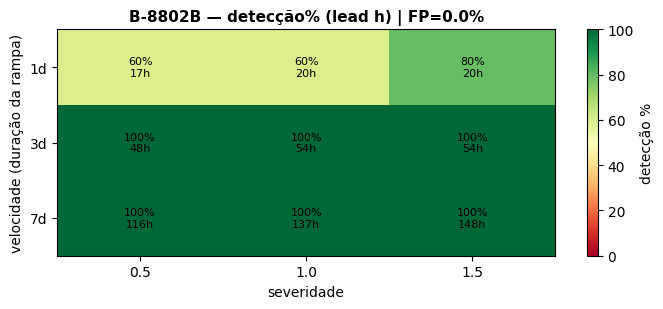

In [3]:
cfg=E['B-8802B']; FAIL=pd.Timestamp('2022-07-06 10:00')
df,_,_=run_preprocessing(load_equipment_data('B-8802B',from_clearml=False),cfg.pre_split_steps)
S=['Vibração Bomba LA','Vibração Bomba LNA','Temperatura Bomba LA']
bm=df.index<FAIL-pd.Timedelta(days=20); real=df[(df.index>=FAIL-pd.Timedelta(days=2))&(df.index<FAIL)]
peak={cc:float(np.percentile(real[cc].dropna(),90)-df[bm][cc].mean()) for cc in S}
thr,fp,res=run_envelope(df,bm,bm,S,peak,99.5,10,12,score='maha')
print(f'threshold={thr:.1f} | FP saudável={fp:.2%}'); SEVS=[0.5,1.0,1.5]; DURS=[1,3,7]
heatmap(res,f'B-8802B — detecção% (lead h) | FP={fp:.1%}',SEVS,DURS,'b8802b_envelope.png')

## B-6511502A — quebra acoplamento (vibração mancal motor LA)

threshold=53.3 | FP saudável=0.46%


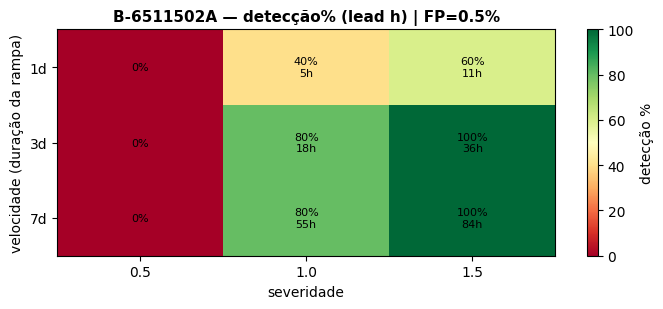

In [4]:
cfg=E['B-6511502A']; FAIL=pd.Timestamp('2023-05-15 00:00')
df,_,_=run_preprocessing(load_equipment_data('B-6511502A',from_clearml=False),cfg.pre_split_steps)
S=[c for c in ['VIB. MANCAL RADIAL MOT LA 90° VE-50B','VIB. MANCAL RADIAL MOT LA 0° VE-51B'] if c in df.columns]
bm=df.index<FAIL-pd.Timedelta(days=20); real=df[df.index>=df.index.max()-pd.Timedelta(days=1)]
peak={cc:float(np.percentile(real[cc].dropna(),90)-df[bm][cc].mean()) for cc in S}
thr,fp,res=run_envelope(df,bm,bm,S,peak,99.5,8,10,score='maha')
print(f'threshold={thr:.1f} | FP saudável={fp:.2%}')
heatmap(res,f'B-6511502A — detecção% (lead h) | FP={fp:.1%}',[0.5,1.0,1.5],[1,3,7],'b6511502a_envelope.png')

## B-4064A — roçamento (resíduo Temp mancal ~ carga); saudável 2025; severidade em °C

limiar=z>2.5 | FP saudável 2025-26=0.00%


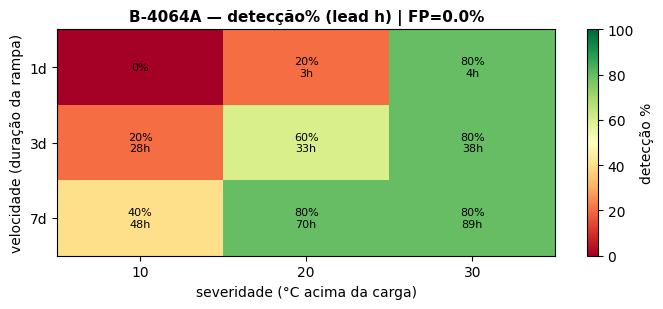

In [5]:
cfg=E['B-4064A-prod']; df,_,_=run_preprocessing(load_equipment_data('B-4064A-prod',from_clearml=False),cfg.pre_split_steps)
df=df[df['Vibração Bomba LNA']>0.2]
bm=df.index.isin(pd.concat([df.loc['2025-02-01':'2025-03-31'],df.loc['2025-09-01':'2025-11-15']]).index)
hm=df.index>='2025-01-01'; peak={'Temperatura Bomba LNA':1.0}  # severidade em °C absolutos (sev=°C)
thr,fp,res=run_envelope(df,bm,hm,['Temperatura Bomba LNA'],peak,2.5,6,8,score='resid',
                        tempcol='Temperatura Bomba LNA',loadcol='Corrente',sevs=(10,20,30))
print(f'limiar=z>2.5 | FP saudável 2025-26={fp:.2%}')
heatmap(res,f'B-4064A — detecção% (lead h) | FP={fp:.1%}',[10,20,30],[1,3,7],'b4064a_envelope.png',sev_label='severidade (°C acima da carga)')

## Conclusões

- **B-8802B — mais robusto.** Pega até falha de meia-severidade que se desenvolve em 3-7 dias
  (100%), com lead de até ~6 dias. FP 0%. Alta confiança no detector.
- **B-6511502A — robusto na severidade real.** Pega a falha de nível real (1.0) quando ela se
  desenvolve gradualmente (3-7 dias → 80%, lead 18-55h); falha súbita (1 dia) → 40%, ~5h. Coerente
  com o lead de ~2 dias observado no evento real.
- **B-4064A — pega falha em desenvolvimento, com lead.** +20°C ao longo de 7 dias → 80% com ~70h de
  lead. Falha rápida/leve (+10°C, 1 dia) é perdida — o piso de ruído térmico. Confirma "alarme de
  fase tardia", mas mostra que uma degradação LENTA é pega com antecedência útil.

**Padrão comum:** o lead time cresce com a velocidade de desenvolvimento — falhas que se desenvolvem
em dias dão muito mais antecedência que falhas súbitas. **Ressalva:** valida variações da forma de
falha conhecida, não modos novos; detecção precoce de banda estreita pede espectro de vibração.